# Text Analytics Lab 2: Word Embeddings and Topic Models 

This lab explores unsupervised methods for learning from text data. Firstly, we use the text representations from the previous lab to identify topics with Latent Dirichlet Allocation (LDA), then show how to adjust term count vectors with TF-IDF. Next, we introduce embedding techniques for learning dense vector representations of words and documents. Building on this idea, we show how to use BERTopic, which uses the idea of learned embeddings to cluster documents.

### Learning Outcomes

After completing this lab, you should be able to...
* Apply Latent Dirichlet Allocation (LDA) and BERTopic to identify topics
* Interpret the outputs of LDA and BERTopic for a specific document or topic 
* Use TF-IDF to improve the vector representations of the documents and recognise its limitations.
* Train simple word embedding models and retrieve embeddings for specific words. 

### Outline

* Implementing LDA Topic Modelling
* TF-IDF vectors
* Visualizing Topic Modelling Results
* Word embeddings
* BERTopic
* Optional: HDP model as an alternative to LDA

## 1: Load the Dataset

Faced with large collection of documents, it is often useful to understand the different themes or topics that are being discussed. For example, what topics are covered in a set of news articles? What issues to customers often complain about in their reviews? 

Topic modelling uses unsupervised learning to extract topics from a collection of documents. Each topic is represented as a probability distribution over words: for example, for a topic related to "space travel" you would expect words like "shuttle" or "moon" to have a high probability, while unrelated words such as "reggae" or "hippopotamus" will have low probability. 

Let's load some data to apply topic modelling to from the 20 newsgroups dataset:

In [1]:
from sklearn.datasets import fetch_20newsgroups

# We will use the 'train' split for learning the topics in an unsupervised manner:
newsgroups_train = fetch_20newsgroups(subset='train', shuffle=True, remove=('headers', 'footers', 'quotes'))

# We will apply our learned topic model to the 'test' split later on:
newsgroups_test = fetch_20newsgroups(subset='test', shuffle=True, remove=('headers', 'footers', 'quotes'))

Newsgroups are internet discussion groups, where users discuss a range of topics, which were popular in the early days of the Internet. Despite the name, the posts do not usually contain news. This dataset contains posts from 20 different newsgroups. Each newsgroup has a particular theme. We can view the list of newsgroups in the training split as follows:

In [2]:
print(newsgroups_train.target_names)

['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


When working with a new dataset, it is always good to play around with the data and see what we have, and how to find everything :) 
```newsgroups_train``` is a Python dictionary. Let's look at the keys and the types of objects stored in the dictionary:

In [3]:
for i in newsgroups_train:
    print(i, type(newsgroups_train[i]))

data <class 'list'>
filenames <class 'numpy.ndarray'>
target_names <class 'list'>
target <class 'numpy.ndarray'>
DESCR <class 'str'>


The ```data``` item is a list of raw text documents. This is all we need for topic modelling, so we can ignore the ```target``` and ```DESCR``` keys for now.

The code below prints out the first post in ```data```:

In [4]:
print('DOCUMENT 0:')
print(newsgroups_train.data[0])

DOCUMENT 0:
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.


## 2: Data Preprocessing

To apply topic modelling, we need to first preprocess the data. We will carry out the following steps:
* Tokenise the posts using NLTK's word_tokenize() function. Topic models are a way of clustering words, so we have to split our text into sequences of words. 
* Remove non-word tokens and tokens with length less than 3 (likely to be numbers and punctuation that are not related to specific topics) and longer than 15 (probably URLs, codes, andbadly formatted tokens rather than proper words). This is a heuristic for cleaning the data.
* Convert the tokens to lower case. This simplifies the vocabulary.
* Remove stopwords: we have not used this step before; it removes tokens such as 'the' and 'a' that appear in a list of very common words, because these words do not tell us much about topics. Stopword removal is not always a good idea, as it can sometimes remove important information, so be careful about when you apply it! For topic modelling, removing stopwords can be  useful to remove noise and reduce the model complexity. 
* Lemmatize the tokens using WordNetLemmatizer to convert verbs to their root forms. This also minimises the vocabulary size. We assume that if a verb is associated with a topic, then all forms of the verb will share this association.  

We're going to use the library [Gensim](https://radimrehurek.com/gensim/), because it contains a lot of useful tools for topic modelling. The preprocessing steps will therefore look a bit different to our first lab, where we used Scikit-learn, as Gensim also comes with useful functions for text normalisation, listing stopwords, and representing words or documents as vectors. Run the code below to preprocess the text:

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
from nltk.stem import WordNetLemmatizer 
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS # find stopwords
import numpy as np

np.random.seed(400)  # We fix the random seed to ensure we get consistent results when we repeat the lab.

# Tokenize and lemmatize
def preprocess(text):
    result=[]
    for token in simple_preprocess(text) :  # Tokenize, remove very short and very long words, convert to lower case, remove words containing non-letter characters
        if token not in STOPWORDS:
            result.append(WordNetLemmatizer().lemmatize(token, 'v'))
            
    return result

# Create a list of preprocessed documents
processed = []
for doc in newsgroups_train.data:
    processed.append(preprocess(doc))

Now that we have finished the preprocessing, we need to construct the input for Gensim's topic modelling method. We do so by constructing a dictionary with word<->id mappings, then converting that into a bag of words, which will be the input to our model.

In [6]:
from gensim.corpora import Dictionary

dictionary = Dictionary(processed) # construct word<->id mappings - it does it in alphabetical order
print(dictionary)

bow_corpus = [dictionary.doc2bow(doc) for doc in processed]

Dictionary<66176 unique tokens: ['addition', 'body', 'bricklin', 'bumper', 'call']...>


# 3. Latent Dirichlet Allocation (LDA)

Now we are ready to perform topic modelling using LDA. 

We are going to try 20 topics in the document corpus: the number of newsgroups is also 20, so perhaps we will find topics that correspond with the newsgroups. We will be running LDA using all CPU cores to parallelize and speed up model training.

Gensim provides the ```LdaModel``` class. When we construct an ```LdaModel``` object, some of the parameters we will be tweaking are:
   * *num_topics*, the number of requested latent topics to be extracted from the training corpus. <br>
   * *id2word*, a mapping from word ids (integers) to words (strings). It is used to determine the vocabulary size, as well as for debugging and topic printing. <br>
   * *workers*, the number of extra processes to use for parallelization. Uses all available cores by default. <br>


In [7]:
from gensim.models import LdaModel

# This call will construct and fit (train) the LDA model:
lda_model =  LdaModel(bow_corpus, 
                      num_topics=20, 
                      id2word=dictionary,                                    
                      passes=10,
                    ) 

**TO-DO 1:** Run the code below to print out the topic distributions found by LDA. Can you find any topics that relate to specific newsgroups (newsgroups_train.target_names)? Can you find any other meaningful topics?

In [8]:
'''
For each topic, we will explore the words occuring in that topic and its relative weight
'''
for idx, topic in lda_model.print_topics(-1):
    print("Topic: {} \nWords: {}".format(idx, topic ))
    print("\n")

Topic: 0 
Words: 0.018*"god" + 0.012*"people" + 0.011*"think" + 0.009*"believe" + 0.009*"know" + 0.007*"jesus" + 0.007*"say" + 0.007*"mean" + 0.006*"point" + 0.005*"come"


Topic: 1 
Words: 0.014*"say" + 0.013*"go" + 0.013*"people" + 0.011*"know" + 0.010*"think" + 0.008*"come" + 0.008*"time" + 0.007*"like" + 0.007*"mr" + 0.007*"want"


Topic: 2 
Words: 0.019*"cx" + 0.015*"c_" + 0.012*"hz" + 0.010*"qs" + 0.009*"entry" + 0.009*"lk" + 0.009*"ck" + 0.008*"ww" + 0.007*"mv" + 0.007*"md"


Topic: 3 
Words: 0.012*"like" + 0.010*"know" + 0.008*"buy" + 0.008*"new" + 0.008*"need" + 0.008*"good" + 0.008*"thank" + 0.008*"use" + 0.008*"work" + 0.008*"price"


Topic: 4 
Words: 0.017*"turkish" + 0.017*"armenian" + 0.012*"armenians" + 0.011*"greek" + 0.010*"turkey" + 0.009*"people" + 0.009*"turks" + 0.009*"government" + 0.008*"war" + 0.007*"militia"


Topic: 5 
Words: 0.017*"file" + 0.015*"key" + 0.013*"program" + 0.013*"use" + 0.007*"information" + 0.007*"include" + 0.007*"data" + 0.006*"number" + 0.0

**TO-DO 2:** What do the values beside each word mean? 

Probability of that word given the topic.

## Testing on unseen data

Now that we have a trained LDA model, we can run it on a new, unseen document to get the breakdown of topics. Let's test the model on a document from the test set. First, get the raw document, then apply preprocessing:

In [9]:
# Set the index below to choose a document:
test_document_idx = 0

# Retrieve the document and print its newsgroup:
unseen_document = newsgroups_test.data[test_document_idx]
print(unseen_document)

print(f' This document is from newsgroup {newsgroups_test.target_names[newsgroups_test.target[test_document_idx]]}')

# Data preprocessing step for the unseen document - It is the same preprocessing we have performed for the training data
bow_vector = dictionary.doc2bow(preprocess(unseen_document))

# Show a bag of words representation of the object:
for idx, count in bow_vector:
    print(f'{dictionary[idx]}: {count}')

I am a little confused on all of the models of the 88-89 bonnevilles.
I have heard of the LE SE LSE SSE SSEI. Could someone tell me the
differences are far as features or performance. I am also curious to
know what the book value is for prefereably the 89 model. And how much
less than book value can you usually get them for. In other words how
much are they in demand this time of year. I have heard that the mid-spring
early summer is the best time to buy.
 This document is from newsgroup rec.autos
early: 1
know: 1
model: 2
hear: 2
summer: 1
time: 2
tell: 1
value: 2
buy: 1
usually: 1
year: 1
little: 1
feature: 1
word: 1
best: 1
book: 2
performance: 1
mid: 1
far: 1
le: 1
differences: 1
spring: 1
demand: 1
se: 1
confuse: 1
curious: 1
prefereably: 1


Now, run our preprocessed document through the LDA model as follows to obtain $\boldsymbol{\theta}^d$, the topic distribution (topics with zero probability are not shown):

In [10]:
topic_distribution = lda_model[bow_vector]

We can examine the word-topic distributions for the topics associated with this document:

In [11]:
for index, probability in sorted(topic_distribution, key=lambda tup: -1*tup[1]):
    print("Index: {}\nProbability: {}\t Topic: {}".format(index, probability, lda_model.print_topic(index, 5)))

Index: 3
Probability: 0.804639458656311	 Topic: 0.012*"like" + 0.010*"know" + 0.008*"buy" + 0.008*"new" + 0.008*"need"
Index: 9
Probability: 0.16721688210964203	 Topic: 0.011*"problem" + 0.010*"like" + 0.009*"time" + 0.009*"try" + 0.008*"window"


**TO-DO 3:** Do these topics seem like a good fit for your selected document?

## Visualising Topics 

Let's compare the topics for some training set documents in the same newsgroup.

**TO-DO 4:** Complete the code below to define a function to retrieve the topic distributions for 10 documents in the ```talk.politics.mideast``` newsgroup.

In [12]:
from gensim.matutils import any2sparse

def get_document_ids_in_newsgroup(newsgroup_name, newsgroups_data):
    # retrieve a list of document indexes for documents with this target_name
    doc_idxs = []
    for i, target_i in enumerate(newsgroups_data.target):
        if newsgroups_data.target_names[target_i] == newsgroup_name:
            doc_idxs.append(i)
            
    #print("There are {} documents in the newsgroup {}".format(len(doc_idxs), newsgroup_name))
            
    return doc_idxs


def get_topic_dists_in_newsgroup(newsgroup_name, lda_model, max_num_docs=10):
    doc_idxs = get_document_ids_in_newsgroup(newsgroup_name, newsgroups_train)
    
    # only use the first ten documents.
    if len(doc_idxs) > max_num_docs:
        doc_idxs = doc_idxs[:max_num_docs]
    print(doc_idxs)
    
    # Save each theta_d distribution to the list 'thetas':
    thetas = []
    
    for doc_idx in doc_idxs:
        ### COMPLETE THE CODE HERE
        bow_vector = dictionary.doc2bow(preprocess(newsgroups_train.data[doc_idx]))
        theta_d = lda_model[bow_vector]

        
        #######################
        
        thetas.append(theta_d)
    
    return thetas

Run the function above and print out the topic distributions:

In [13]:
thetas = get_topic_dists_in_newsgroup('talk.politics.mideast', lda_model, max_num_docs=10)
print(thetas)

[33, 54, 70, 91, 104, 133, 152, 160, 202, 219]
[[(1, 0.27720204), (3, 0.07955769), (4, 0.07350514), (14, 0.021714706), (15, 0.5394855)], [(0, 0.043880448), (1, 0.20372298), (3, 0.014271889), (4, 0.50504404), (5, 0.037394408), (9, 0.021045912), (10, 0.04312441), (13, 0.12297323)], [(0, 0.046009745), (1, 0.14230074), (4, 0.7124396), (9, 0.012894615), (13, 0.06942252)], [(0, 0.16094081), (1, 0.048470147), (4, 0.44132137), (12, 0.24160346), (13, 0.063831866), (15, 0.035862327)], [(0, 0.402749), (4, 0.20838352), (9, 0.20895228), (13, 0.031128742), (15, 0.13433477)], [(1, 0.399618), (4, 0.43631154), (5, 0.041233037), (12, 0.025465144), (13, 0.08679248)], [(0, 0.17467265), (3, 0.14015684), (12, 0.13096623), (13, 0.24819976), (14, 0.03159647), (15, 0.26439056)], [(1, 0.4050058), (4, 0.10257617), (6, 0.10720718), (15, 0.3009969), (16, 0.054206766)], [(0, 0.1934433), (1, 0.3385143), (3, 0.14479457), (9, 0.069628544), (13, 0.17736526), (17, 0.045692943)], [(0, 0.19455133), (1, 0.12079047), (2, 0.

The text output is quite hard to read. We can improve on it by making a bar chart with a distinct colour for each topic. The function below can be used to plot a simple bar chart using the ```matplotlib``` library. This will help us see which documents discuss the same topics. The height of each bar is the probability for that topic within the document, according to our model.

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# choose some colours for the topics
colours = ['blue', 'green', 'red', 'cyan', 'magenta', 'yellow', 'black', 'teal', 'pink', 'purple',
           'orange', 'gray', 'lime', 'darkgreen', 'lightgray', 'navy', 'gold', 'crimson', 'darkgray', 'fuchsia']

def convert_theta_sparse_to_dense(theta_d_sparse, num_topics):
    theta_d = np.zeros(num_topics)  # an empty array
    
    # split the output from lda_model into two lists
    active_topics_in_d, probs = map(list, zip(*theta_d_sparse))
    
    # record the values in theta_d
    for i, topic in enumerate(active_topics_in_d):
        if topic >= num_topics:
            break
            
        theta_d[topic] = probs[i]
    
    return theta_d

# a function for producing a bar chart for a document
def plot_theta(thetas, d, num_docs, num_topics):
    plt.subplot(int(num_docs/3) + 1, 3, d+1)   # make a set of subplots inside a figure, with four subplots per row
    
    theta_d = convert_theta_sparse_to_dense(thetas[d], num_topics)
    
    # plot the results so that the same topics always occur at the same place along the x axis.
    plt.bar(x=np.arange(len(theta_d)), height=theta_d, color=colours, tick_label=np.arange(num_topics))

**TO-DO 5:** Use the function to plot the topic distributions of the 10 documents we selected from the ```talk.politics.mideast``` newsgroup. What do you notice? Are there any topics the documents have in common? Any they do not? Refer back to the printed list of topics above to find the most common topic in this newsgroup.

ANSWER: Magenta topic is tall in almost every subplot. While blue appears with high probability in only 3-4 topics. 

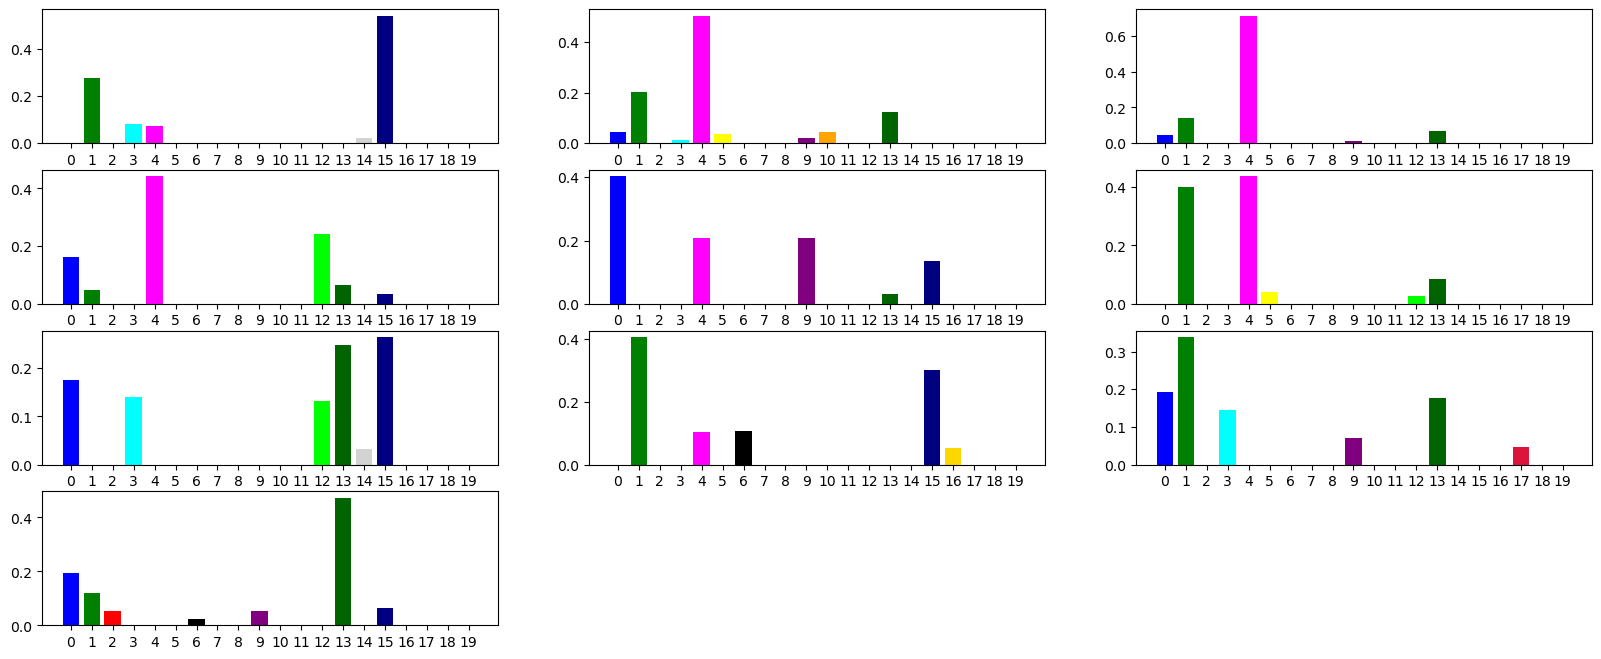

In [15]:
plt.figure(figsize=(20,8))

### WRITE YOUR OWN CODE HERE
num_docs = len(thetas)
for d in range(num_docs):
    plot_theta(thetas, d, num_docs, 20)

############################

plt.show()

Now, let's look at how the topics we've found with LDA relate to the newsgroups (the targets in the training set).

The code below iterates over the newsgroups, computing the topic distribution for each document in that particular newsgroup. 

**TO-DO 6:** Complete the function below to compute the mean topic distribution, $\boldsymbol\theta$, for each newsgroup. Hint: use the ```mean``` function from Numpy. 

In [16]:
# Create a numpy array which will store a matrix of values. Rows correspond to newsgroups and columns to LDA topics.
def get_newsgroups_mean_topics(lda_model, num_topics):
    
    # Create a matrix where each row corresponds to a newsgroup, and each column to a topic.
    # In each entry, we will save the mean probability of the topic for the documents in that newsgroup.
    mean_thetas = np.zeros((len(newsgroups_train.target_names), num_topics))

    print(mean_thetas.shape)
    for t, target_name in enumerate(newsgroups_train.target_names):
        # Obtain the thetas for the documents with this target name
        thetas_t_sparse = get_topic_dists_in_newsgroup(target_name, lda_model, max_num_docs=10)
        
        print(thetas_t_sparse)
        
        # convert the thetas to a dense vector format
        thetas_t = []
        for theta_d_t_sparse in thetas_t_sparse:
            if not theta_d_t_sparse:
                continue  # if it's empty
            thetas_d = convert_theta_sparse_to_dense(theta_d_t_sparse, num_topics)
            thetas_t.append(thetas_d)
            
        # compute the mean theta for this newsgroup and store it in mean_thetas 
        
        ### WRITE YOUR OWN CODE HERE
        mean_thetas[t] = np.mean(thetas_t, axis=0)
        ###########################

        #print(mean_thetas[t])
    return mean_thetas

We can now plot a matrix ```mean_thetas``` using ```matplotlib``` using the code below. This shows how much of the text within each newsgroup relates to each LDA topic. So, a more yellow square means that the newsgroup is more strongly associated with that topic. 

**TO-DO 7:** which LDA topics are common across many newsgroups? Are there any topics that are specific to particular newsgroups? 

ANSWER: Topics 1 and 13 appear accorss many newsgroups. Topic 14 seems to map almost strictly to space.

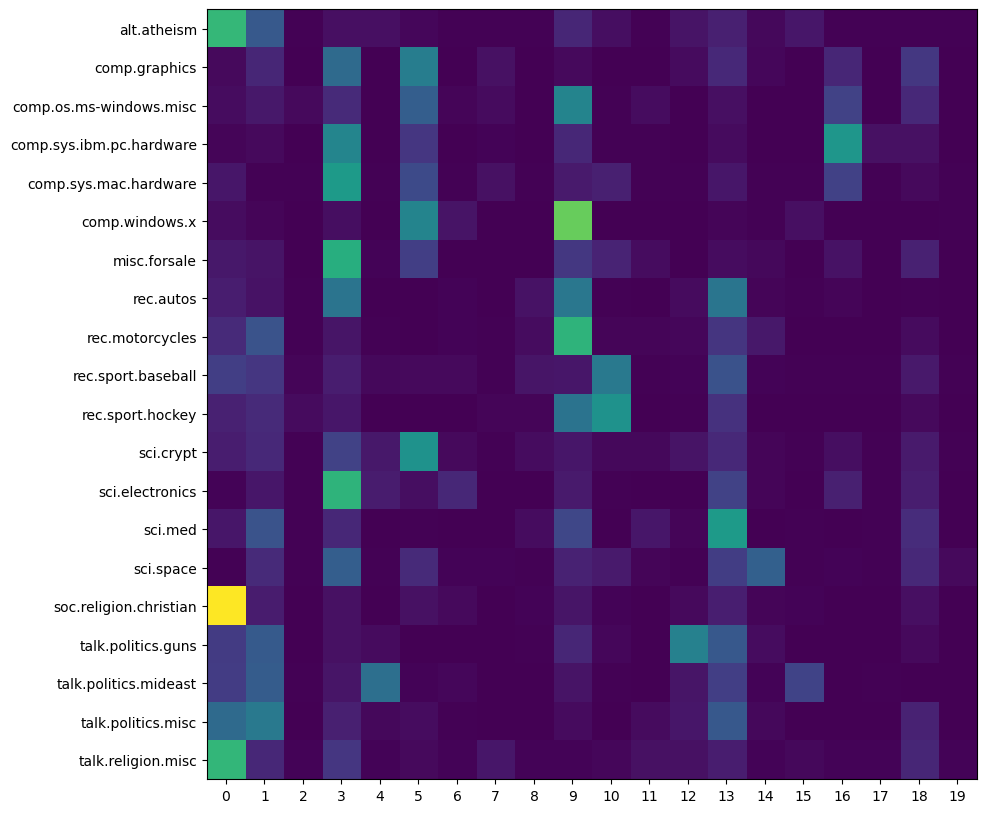

In [17]:
from IPython.display import clear_output

def plot_newsgroup_topic_matrix(model, num_topics):
    # Run the function we defined above to get the mean topic distributions:
    mean_thetas = get_newsgroups_mean_topics(model, num_topics)
    
    print(f'mean_thetas is a matrix of shape {mean_thetas.shape}')

    # Create a new figure
    plt.figure(figsize=(20,10))
    clear_output()

    # Plot the matrix as a 2-D grid, where colours represent the values.
    plt.imshow(mean_thetas)

    # Change the labels on the axes
    plt.yticks(range(len(newsgroups_train.target_names)), newsgroups_train.target_names )
    plt.xticks(range(num_topics))

    plt.show()
    
plot_newsgroup_topic_matrix(lda_model, 20)

# 4. TF-IDF

So far for LDA we have used a bag of words to represent each document. Despite removing stopwords, the unigram feature counts can still emphasise common words that are not very helpful for distinguishing between topics. To see this, let's take a document from the 'rec.autos' newsgroup as a 'query' document and print out the document and its bag of words vector:

In [18]:
doc_idxs = get_document_ids_in_newsgroup('rec.autos', newsgroups_train)
doc_idx_0 = doc_idxs[19]
print(newsgroups_train.data[doc_idx_0].strip())
query_doc = bow_corpus[doc_idx_0]
# show the bag of words vector in sparse format. In each pair of numbers, the first is the word ID and the second is the word count.

query_doc.sort(key=lambda tup: -1*tup[1])  # sort the bag of words vector for the query document in descending order of word count
for idx, count in query_doc:  
    print(f'{dictionary[idx]}: {count}')

From article <1993Apr5.200048.23421@ucsu.Colorado.EDU>, by lorenzo@rintintin.Colorado.EDU (Eric Lorenzo):

--Let me put it like this.  The only similarity between the three models
  is the "300", or 3-liter engine displacement.  Actually, the SC300 (the
  coupe) and the GS300 (the funky-looking new sedan) share the same 3.0
  liter inline-six, and the ES300 (popular small sedan) uses 3.0 V6 shared
  with the Camry.  The SC300 is a luxury/sports coupe, the GS300 is the new
  luxury sedan, and the ES300 is the base executive sedan.  All three look
  completely different.

--Aamir Qazi
--
sedan: 4
look: 2
share: 2
edu: 2
new: 2
luxury: 2
sc: 2
colorado: 2
es: 2
gs: 2
coupe: 2
liter: 2
lorenzo: 2
engine: 1
funky: 1
model: 1
small: 1
sport: 1
base: 1
actually: 1
like: 1
use: 1
article: 1
different: 1
let: 1
apr: 1
completely: 1
inline: 1
eric: 1
executive: 1
popular: 1
aamir: 1
camry: 1
displacement: 1
qazi: 1
rintintin: 1
similarity: 1
ucsu: 1


In some cases, we can improve the vector representations from a pure bag of words using TF-IDF to focus more on keywords that distinguish one document from the others. Our usual bag of words vector contains word counts -- these values are otherwise known as 'term frequencies' or TF.

TF-IDF is computed from two terms. First, the log of the term frequency:
$$ tf(t,d) = count(t,d)$$

Term frequency captures how much that term occurs in a document, as a way of capturing its importantance to that document. However, we now want to down-weight terms that are common in every document so that the distinctive keywords have the highest values. To do this, we multiple the log term frequency by the inverse document frequency, which is computed like this:

$$ idf(t) = \log_{2}\frac{N}{df(t)}$$

Document frequency captures how many documents the term occurs in, thus measuring how common the term is across the whole dataset. By taking an inverse, terms with high document frequency will be down-weighted. 

Gensim provides the TfidfModel class to compute TF-IDF vectors from our existing corpus object:

In [19]:
from gensim.models import TfidfModel

tfidf_model = TfidfModel(bow_corpus)

**TO-DO 8:** Apply the tfidf_model to `query_doc`, our randomly selected document from the newsgroups dataset. Print the results to see how the values differ from the previous bag of words. Hint: you can apply the model in the same was a you applied lda_model to a bow_vector for an unseen test document.

In [20]:
#### WRITE YOUR OWN CODE HERE
tfidf_vector = tfidf_model[query_doc]
for idx, score in sorted(tfidf_vector, key=lambda tup: -tup[1]):
    print(f'{dictionary[idx]}: {score}')


#####

sedan: 0.501309433082274
lorenzo: 0.30495411379309023
coupe: 0.2735781334056121
liter: 0.2536187490774376
luxury: 0.24535560099580858
es: 0.2184736905773415
gs: 0.21293643505986085
sc: 0.20228338436178492
colorado: 0.17779137655976476
rintintin: 0.15247705689654512
aamir: 0.14715053154750715
qazi: 0.14715053154750715
displacement: 0.1430189575066927
share: 0.14237756160123438
funky: 0.13964321571763197
ucsu: 0.13964321571763197
inline: 0.134316690368594
camry: 0.13018511632777952
similarity: 0.1253273582705685
executive: 0.10406024237029715
eric: 0.09078022733619136
edu: 0.0905859614876229
popular: 0.08448746611867301
sport: 0.083126544585797
engine: 0.08080053517210412
new: 0.07767016481120734
apr: 0.07606184710096922
look: 0.07308708158574487
completely: 0.07253738709047512
model: 0.06561525420274841
small: 0.05995207741528221
article: 0.05775276235158468
different: 0.05286654107735494
actually: 0.05197807946943947
base: 0.051602393440981144
let: 0.04666511349048709
use: 0.0339947640

**TO-DO 9:** Rerun LDA using TF-IDF vectors and print the topic-word distributions. Do you notice any differences in the topics?
Answer: The generic words are gone but the words in each topic look less related and coherent.

In [21]:
tfidf_corpus = [tfidf_model[doc] for doc in bow_corpus]

### WRITE YOUR ANSWER HERE

lda_tfidf = LdaModel(tfidf_corpus, num_topics=20, id2word=dictionary, passes=10)
for idx, topic in lda_tfidf.print_topics(-1):
    print("Topic: {} \nWords: {}".format(idx, topic))
    print("\n")

    
######

Topic: 0 
Words: 0.002*"forsale" + 0.002*"grayscale" + 0.002*"risc" + 0.001*"deskjet" + 0.001*"volvo" + 0.001*"ink" + 0.001*"lane" + 0.001*"compartment" + 0.001*"paradox" + 0.001*"interlace"


Topic: 1 
Words: 0.002*"irq" + 0.002*"fpu" + 0.002*"ati" + 0.002*"diet" + 0.002*"patent" + 0.002*"ohio" + 0.002*"ripem" + 0.002*"select" + 0.001*"moment" + 0.001*"reader"


Topic: 2 
Words: 0.002*"tonight" + 0.001*"vax" + 0.001*"cds" + 0.001*"dodgers" + 0.001*"maine" + 0.001*"alan" + 0.001*"solder" + 0.001*"mercury" + 0.001*"trunk" + 0.001*"illinois"


Topic: 3 
Words: 0.003*"nt" + 0.003*"pen" + 0.003*"gif" + 0.002*"digital" + 0.002*"frame" + 0.002*"manager" + 0.002*"centris" + 0.002*"trace" + 0.002*"client" + 0.002*"thanx"


Topic: 4 
Words: 0.003*"ax" + 0.002*"bmw" + 0.002*"nec" + 0.002*"iran" + 0.001*"ra" + 0.001*"toshiba" + 0.001*"stack" + 0.001*"customer" + 0.001*"protocol" + 0.001*"lh"


Topic: 5 
Words: 0.004*"cd" + 0.003*"motorcycle" + 0.003*"rom" + 0.003*"helmet" + 0.003*"dog" + 0.002*"o

# 5. Word Embeddings

In this section, you will explore word embeddings: vector representations that have themselves been learned from unlabelled text data. These embeddings encode information about a word's meaning, making them useful for representing text as input to a topic model or classifier. 

First, consider the bag-of-words and TF-IDF vectors above. THey are sparse, with many zeros and a dimension for each term in the vocabulary. They do not capture complex relations between words very well, e.g., synonyms are treated as unrelated. _Word embeddings_ address this problem by mapping each word to a vector representation. Documents can then be represented by aggregating word vectors, or we can pass sequences of word embeddings into neural networks (coming up in future weeks!). 

This idea became successful afeter Mikolov et al. published a paper on their ``word2vec`` package in 2013. Importantly, the word embeddings can be learned from lots of text without any labelling, and learn to capture general aspects of semantics (meaning) and syntax that apply to many different problems. The word2vec approach is to train classifiers to predict how frequently pairs of words occur in the same context, i.e., within a few words of each other in a document in the training set. For each word in the vocabulary, we learn a logistic regression classifier, and its weights can be used as a vector that represents the word. This weight vector is a by-product of the training task that happens to encode a lot of useful information about word semantics: words that occur in similar contexts typically have some kind of relationship, and will end up with similar weight vectors. 

Let's first use Gensim to train a word2vec model. The code below tokenizes the training texts, then runs word2vec (the _skipgram_ variant) to learn a set of embeddings. 

In [22]:
from gensim.models import word2vec
from gensim.utils import tokenize

raw_text = newsgroups_train.data  # get the training documents as a text corpus for learning embeddings

tokenized_texts = [list(tokenize(text)) for text in raw_text]
emb_model = word2vec.Word2Vec(tokenized_texts, sg=1, min_count=1, window=3, vector_size=100)

We can look up the embedding for any given word like this:

In [23]:
emb_model.wv['happy']

array([-0.38572887,  0.04585682, -0.02504718,  0.36531016,  0.6502457 ,
       -0.28187716,  0.18641923,  0.16929908,  0.24060024, -0.543355  ,
        0.38168487, -0.6877145 , -0.9034604 ,  0.19850346, -0.11352803,
        0.75649905,  0.3304206 ,  0.01301391,  0.12762159, -0.11946926,
        0.21963762, -0.05525216,  0.50392145, -0.7417906 ,  0.83640695,
        0.46390596,  0.14154276,  0.13487074,  0.08599153,  0.07970787,
        0.6191191 ,  0.01105673, -0.12494342,  0.30384442,  0.18449304,
       -0.0566289 ,  0.24334787,  0.19055076,  0.13851428, -0.40779096,
        0.29772955,  0.26772887, -0.19619834, -0.05757247, -0.3444558 ,
        0.76475996,  0.3496085 , -0.36250547, -0.3679709 ,  0.03361248,
        0.3355848 , -0.09488086,  0.35928348,  0.0736862 , -0.34814224,
       -0.25051525,  0.5172222 , -0.01053212, -0.47099164,  0.33531973,
       -0.37929517, -0.0582215 , -0.15211092, -0.68492085, -0.06427104,
        0.15633452,  0.2726109 , -0.1323227 ,  0.14427258,  0.66

Gensim provides a useful method for finding the most similar words. Internally, this uses cosine similarity to compare embeddings. Let's try it out:

In [24]:
emb_model.wv.similar_by_word('happy', topn = 5)

[('satisfied', 0.8940267562866211),
 ('comfortable', 0.8915091156959534),
 ('unhappy', 0.8834189772605896),
 ('pleased', 0.8800750374794006),
 ('proud', 0.8793904781341553)]

Above, we trained our own model using the skipgram method. We can also download a pretrained model that has previously been trained on a large corpus -- this means that we do not need to train our own model, or get hold of a large dataset ourselves. Instead, we can take advantage of a model that was trained on much more data and can provide high-quality embeddings. The idea of sharing pretrained representations of data is really powerful: we don't need to train from scratch for each new task we do, which would be very expensive and require a lot of data; we can just reuse some suitable embeddings to make the task of training much easier and cheaper. 

There is a list of embedding models available [here](https://radimrehurek.com/gensim/models/word2vec.html#pretrained-models). Let's try out GLoVe embeddings. GLoVe is an alternative to the skipgram model. This model was trained on a corpus of tweets, so it may encode different relationships to our previous model. When do you think it would be useful to use embeddings trained on Tweets? Do you think they would be suitable for processing legal documents? 


In [25]:
import gensim.downloader

glove_wv = gensim.downloader.load('glove-twitter-25')

print(glove_wv['happy'])

[-1.2304   0.48312  0.14102 -0.0295  -0.65253 -0.18554  2.1033   1.7516
 -1.3001  -0.32113 -0.84774  0.41995 -3.8823   0.19638 -0.72865 -0.85273
  0.23174 -1.0763  -0.83023  0.10815 -0.51015  0.27691 -1.1895   0.98094
 -0.13955]


**TO-DO 10:** Find the most similar five words to 'happy' according to the GloVe Twitter model.

In [26]:
# WRITE YOUR OWN CODE HERE
glove_wv.similar_by_word('happy', topn=5)

[('birthday', 0.9577817320823669),
 ('thank', 0.9376668334007263),
 ('welcome', 0.9336148500442505),
 ('love', 0.9176183342933655),
 ('miss', 0.9164499640464783)]

Notice that a different set of words are favoured than with word2vec, and consider how this might result from pretraining the embeddings on Twitter data.

# 6. BERTopic

https://maartengr.github.io/BERTopic/index.html

Rather than relying on sparse vector representations, as in LDA, can we make use of pretrained word embeddings that better capture the meaning of words, to find more meaningful topics? BERTopic is one such approach for this. BERTopic is a pipeline method with several steps:

Embedding documents --> Dimensionality reduction --> Clustering --> \[cluster labelling: Tokenizer --> Token weighting scheme\]

The first step uses a method called SBERT to embed each document to single dense vector. SBERT uses the same principles as the word2vec method above: it uses a large corpus of unlabelled data and trains a model to predict words from their contexts. This results in a model that can produce embeddings of the words in a document. The individual word embeddings are aggregated (usually by taking an average) to form a document embedding. We will learn more about how SBERT works in future weeks. 

Dimensionality reduction (e.g., PCA) is then used to reduce the size of the embeddings further, as clustering works more effectively in lower dimensions. Clustering groups documents with similar embeddings. 

**TO-DO 11**: How does this assignment of documents to clusters differ from the way that LDA assigns topics to documents? 

ANSWER: BERTopic is hard topic assignment while LDA is probabilistic.

Each cluster is a collection of documents, and the last two steps attempt to label each cluster. To do this, we tokenize all of the documents in one cluster, then we can count up how many times each term occurs in that cluster. We could take the most frequent words in each cluster as its 'label', but this will include a lot of very common words, so we apply TF-IDF to emphasise the distinctive keywords. 

Let's try out the BERTopic library:

In [27]:
!pip install bertopic umap-learn  # If you don't have it installed already, install it now

ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [28]:
from bertopic import BERTopic

topic_model = BERTopic()  # run the topic model with default settings. You can also specify the components of the topic model as arguments to the BERTopic constructor, but we will not do that in this lab. See the BERTopic documentation for more details.
topics, probs = topic_model.fit_transform(newsgroups_train.data)

We can display the topics and their labels, ordered by frequency. What do you think topic label '-1' means? Hint: the clustering algorithm is DBScan, which does not place every single document into a cluster.

In [29]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,3789,-1_to_the_and_of,"[to, the, and, of, is, you, for, it, in, that]",[[text deleted]\n\nI wish that you had followe...
1,0,516,0_patients_msg_of_medical,"[patients, msg, of, medical, is, it, in, healt...",[------------- cut here -----------------\n\n\...
2,1,449,1_he_year_his_game,"[he, year, his, game, team, pitching, baseball...",[I thought I'd post my predicted standings sin...
3,2,439,2_team_550_hockey_play,"[team, 550, hockey, play, season, game, 25, nh...",[The FLYERS closed out the season last night w...
4,3,432,3_space_launch_nasa_lunar,"[space, launch, nasa, lunar, orbit, satellite,...",[Archive-name: space/probe\nLast-modified: $Da...
...,...,...,...,...,...
140,139,11,139_plastic_paint_wax_scratches,"[plastic, paint, wax, scratches, car, polish, ...",[\nSuggest McQuires #1 plastic polish. It wil...
141,140,11,140_god_opposites_jesus_gods,"[god, opposites, jesus, gods, my, love, you, w...","[The primary problem in human nature is a ""fra..."
142,141,11,141_tempest_monitor_compariators_compariator,"[tempest, monitor, compariators, compariator, ...",[\n:In article <Apr18.194927.17048@yuma.ACNS.C...
143,142,10,142_reserve_selective_naval_service,"[reserve, selective, naval, service, c17, mari...",[Here is a press release from the Reserve Offi...


We can also see the top words in each topic:

In [30]:
topic_model.get_topic(0)

[('patients', 0.008311745460489526),
 ('msg', 0.007704862222564989),
 ('of', 0.007248619006391585),
 ('medical', 0.0070610360545731105),
 ('is', 0.00702649118768017),
 ('it', 0.00685606836922542),
 ('in', 0.00681934637602617),
 ('health', 0.006685065405097041),
 ('disease', 0.006540591847039623),
 ('food', 0.006489677884818414)]

We can also look at information about each document and visualise the relationships between topics:

In [31]:
topic_model.get_document_info(newsgroups_train.data)

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,I was wondering if anyone out there could enli...,10,10_car_cars_engine_ford,"[car, cars, engine, ford, models, toyota, seda...",[\nI would be concerned about how the car was ...,car - cars - engine - ford - models - toyota -...,0.726648,False
1,A fair number of brave souls who upgraded thei...,16,16_fpu_speed_mhz_clock,"[fpu, speed, mhz, clock, performance, 040, cpu...",[\n\n\n\n Apple has really confused people ...,fpu - speed - mhz - clock - performance - 040 ...,0.755979,False
2,"well folks, my mac plus finally gave up the gh...",7,7_motherboard_ram_sale_card,"[motherboard, ram, sale, card, price, drive, o...",[I saw the following computer in a store and w...,motherboard - ram - sale - card - price - driv...,0.965075,False
3,\nDo you have Weitek's address/phone number? ...,-1,-1_to_the_and_of,"[to, the, and, of, is, you, for, it, in, that]",[[text deleted]\n\nI wish that you had followe...,to - the - and - of - is - you - for - it - in...,0.000000,False
4,"From article <C5owCB.n3p@world.std.com>, by to...",3,3_space_launch_nasa_lunar,"[space, launch, nasa, lunar, orbit, satellite,...",[Archive-name: space/probe\nLast-modified: $Da...,space - launch - nasa - lunar - orbit - satell...,0.869740,False
...,...,...,...,...,...,...,...,...
11309,DN> From: nyeda@cnsvax.uwec.edu (David Nye)\nD...,0,0_patients_msg_of_medical,"[patients, msg, of, medical, is, it, in, healt...",[------------- cut here -----------------\n\n\...,patients - msg - of - medical - is - it - in -...,1.000000,False
11310,"I have a (very old) Mac 512k and a Mac Plus, b...",-1,-1_to_the_and_of,"[to, the, and, of, is, you, for, it, in, that]",[[text deleted]\n\nI wish that you had followe...,to - the - and - of - is - you - for - it - in...,0.000000,False
11311,I just installed a DX2-66 CPU in a clone mothe...,-1,-1_to_the_and_of,"[to, the, and, of, is, you, for, it, in, that]",[[text deleted]\n\nI wish that you had followe...,to - the - and - of - is - you - for - it - in...,0.000000,False
11312,\nWouldn't this require a hyper-sphere. In 3-...,20,20_den_points_polygon_algorithm,"[den, points, polygon, algorithm, xxxx, sphere...","[\nSorry!! :-)\n\nCall the four points A, B, C...",den - points - polygon - algorithm - xxxx - sp...,1.000000,False


In [32]:
topic_model.visualize_topics()

**TO-DO 12:** Let's see if BERTopic has produced a strong association between newsgroups and topics. The function below counts up how many documents in each newsgroup are assigned to each topic. Use this to visualise a matrix mapping topics to newsgroups, similar to the one you produced for LDA. Do you see any strong topic associations?

**TO-DO 13:** Referring to the documentation for BERTopic, alter the arguments to the BERTopic constructor to see if you can improve the results. For example, by changing the minimum cluster size. 

In [33]:
doc_info = topic_model.get_document_info(newsgroups_train.data)
num_topics = len(topic_model.get_topic_info()) - 1  # the number of topics is one less than the number of rows in topic_info, because one row corresponds to outliers which are not assigned to any topic.

def get_bertopic_dists(max_num_docs=10):
    
    count_topics = np.zeros((len(newsgroups_train.target_names), num_topics))  # an array with one entry per topic. 
    
    for t, newsgroup_name in enumerate(newsgroups_train.target_names):
        doc_idxs = get_document_ids_in_newsgroup(newsgroup_name, newsgroups_train)
        
        # only use the first ten documents.
        if len(doc_idxs) > max_num_docs:
            doc_idxs = doc_idxs[:max_num_docs]
        
        for doc_idx in doc_idxs:
            # Get the document from newsgroups_train
            topic_for_doc = doc_info.loc[doc_idx]['Topic']
            if topic_for_doc != -1:  # if the document is not an outlier
                count_topics[t, topic_for_doc] += 1  # increment the count for the topic assigned to this document    

    count_topics /= np.sum(count_topics, axis=1)[:, None]  # normalise the counts to get a distribution over topics for this newsgroup

    return count_topics


count_topics = get_bertopic_dists(max_num_docs=100)

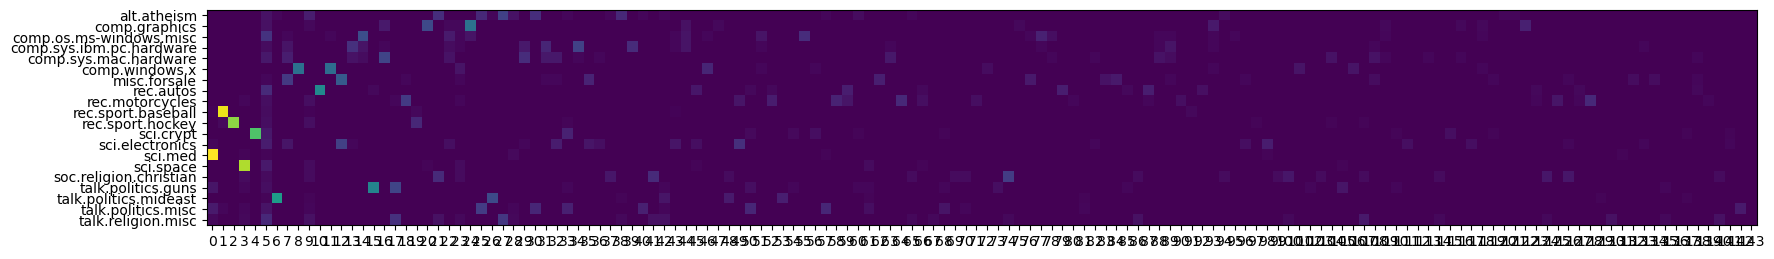

In [34]:
### WRITE YOUR OWN CODE HERE
def plot_newsgroup_topic_matrix(count_topics):
    
    print(f'count_topics is a matrix of shape {count_topics.shape}')

    # Create a new figure
    plt.figure(figsize=(20,10))
    clear_output()

    # Plot the matrix as a 2-D grid, where colours represent the values.
    plt.imshow(count_topics)

    # Change the labels on the axes
    plt.yticks(range(len(newsgroups_train.target_names)), newsgroups_train.target_names )
    plt.xticks(range(num_topics))

    plt.show()
    
plot_newsgroup_topic_matrix(count_topics)

###

# 7. Optional: Hierarchical Dirichlet Process (HDP)

This section is optional if you want to learn more about HDP as an alternative to LDA. HDP allows the number of topics to grow to fit the dataset, so it is not fixed in advance. 

There is an implementation of the [HDP model provided by gensim](https://radimrehurek.com/gensim/models/hdpmodel.html). Instead of passing in a fixed number of topics, HDP will try to learn a good number of topics to fit the data. It does not always give better results than LDA, but can be effective in some situations.

**OPTIONAL TO-DO 14:** Refer to the documentation for HDP and train an HDP model. Hint: reuse the ```bow_corpus``` and ```dictionary``` as arguments in the same way that you did to construct the ```LdaModel``` object.

Use the trained HDP model to obtain mean topic distributions for each newsgroup in the test set with ```get_newsgroups_mean_topics()```. Plot the mean topic matrix as above and compare it to the results from LDA. Set alpha and gamma to 0.01.

In [ ]:
from gensim.models import HdpModel

### WRITE YOUR OWN CODE HERE



###

# print the word-topic distributions for 
for idx, topic in hdp_model.print_topics(20):
    print("Topic: {} \nWords: {}".format(idx, topic ))
    print("\n")

The previous cell shows the first 20 topics. HDP learns the number of topics that are needed to model the dataset. It produces a global distribution over the topics. Topics with very low probability can be considered inactive:

In [ ]:
def plot_global_topic_weights(hdp_model):
    global_topic_weights = hdp_model.m_varphi_ss / np.sum(hdp_model.m_varphi_ss)

    plt.bar(np.arange(len(global_topic_weights)), global_topic_weights)
    plt.ylabel('Probability')
    plt.xlabel('Topic ID')
    
plot_global_topic_weights(hdp_model)

Run the code below to visualise the topics that HDP finds for each newsgroup:

In [ ]:
plot_newsgroup_topic_matrix(hdp_model, 20)

The alpha and gamma arguments to HdpModel control the 'concentration' of topics. Varying these parameters therefore affects the number of topics that HDP finds -- whether it tends towards many fine-grained topics, or few coarse-grained topics.

**OPTIONAL TO-DO 15:** Change the values of alpha and gamma for the HDP model and see what their effect is. Hint: to see noticable differences, change the values by a factor of 10. 

In [ ]:
### WRITE YOUR OWN CODE HERE

###

# print the word-topic distributions for 
for idx, topic in hdp_model.print_topics(20):
    print("Topic: {} \nWords: {}".format(idx, topic ))
    print("\n")
    
plot_global_topic_weights(hdp_model2)
    

In [ ]:
plot_newsgroup_topic_matrix(hdp_model2, 20)